In [1]:
import os
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# ------------------------------
# Plot style
# ------------------------------
matplotlib.rcParams.update({
    'font.size': 20,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.major.size': 6,
    'ytick.minor.size': 3,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'xtick.top': True,
    'ytick.right': True,
    'xtick.bottom': True,
    'ytick.left': True,
    
    'text.usetex': True,  # Enable LaTeX rendering
    'font.family': 'serif',
    'font.serif': ['Computer Modern'],  # LaTeX default font
})


compas_configs = [
    {"tag": "fiducial",
     "match_any": ["fiducial"],
     "label": r"Fiducial",
     "color": "k",
     "ls": "-"},

    {"tag": "alpha0_5",
     "match_any": ["alpha-0_5", "alpha-0.5", "alpha0_5"],
     "label": r"$\alpha_{\rm CE}=0.5$",
     "color": "C0",
     "ls": "--"},

    {"tag": "alpha2",
     "match_any": ["alpha-2_0", "alpha-2", "alpha2"],
     "label": r"$\alpha_{\rm CE}=2$",
     "color": "C1",
     "ls": "-."},

    {"tag": "alpha10",
     "match_any": ["alpha-10", "alpha10"],
     "label": r"$\alpha_{\rm CE}=10$",
     "color": "C2",
     "ls": ":"},

    {"tag": "rapid",
     "match_any": ["rapid"],
     "label": r"Rapid SN",
     "color": "C3",
     "ls": "-"},

    {"tag": "ccsn30kms",
     "match_any": ["ccsn30kms"],
     "label": r"$\sigma_{\rm BH}=30\ \mathrm{km/s}$",
     "color": "C4",
     "ls": "--"},

    {"tag": "ccsn100kms",
     "match_any": ["ccsn100kms"],
     "label": r"$\sigma_{\rm BH}=100\ \mathrm{km/s}$",
     "color": "C5",
     "ls": "--"},

    {"tag": "MT_0_5",
     "match_any": ["MT-0_5", "MT-0.5", "MT_0_5"],
     "label": r"$\beta=0.5$",
     "color": "C6",
     "ls": "-."},

    {"tag": "MT_0_25",
     "match_any": ["MT-0_25", "MT-0.25", "MT_0_25"],
     "label": r"$\beta=0.25$",
     "color": "C7",
     "ls": ":"},

    {"tag": "WR_0_1",
     "match_any": ["WR-0_1", "WR-0.1", "WR_0_1"],
     "label": r"$f_{\rm WR}=0.1$",
     "color": "C8",
     "ls": "-"},

    {"tag": "WR_5",
     "match_any": ["WR-5", "WR_5"],
     "label": r"$f_{\rm WR}=5$",
     "color": "C9",
     "ls": "--"},
]

# ------------------------------------------------------------
# Yield files
# ------------------------------------------------------------
yield_files = [
    '../data/yields/compas-alpha-0_1.hdf5',
    '../data/yields/compas-alpha-2_0.hdf5',
    '../data/yields/compas-fiducial.hdf5',
'../data/yields/compas-rapid.hdf5',
    '../data/yields/compas-ccsn100kms.hdf5',
    '../data/yields/compas-ccsn30kms.hdf5',
    '../data/yields/compas-MT-0_25.hdf5',
    '../data/yields/compas-alpha-10.hdf5',
    '../data/yields/compas-alpha-0_5.hdf5',
    '../data/yields//compas-WR-0_1.hdf5',
    '../data/yields/compas-WR-5.hdf5',
    '../data/yields/compas-MT-0_5.hdf5'
]

def compute_percent_mrr(h5_path):
    with h5.File(h5_path, "r") as f:
        z_vals = f["z_values"][()]
        Y      = f["yields"][()]
        m1     = f["event_properties/mass_1"][()]
        m2     = f["event_properties/mass_2"][()]

    MRR = (m2 > m1)          # as in your snippet
    Rz_total = Y.sum(axis=1)
    Rz_MRR   = Y[:, MRR].sum(axis=1)

    percent = np.full_like(Rz_total, np.nan, dtype=float)
    ok = Rz_total > 0
    percent[ok] = 100.0 * Rz_MRR[ok] / Rz_total[ok]

    return z_vals, percent

def find_matching_file(cfg, files):
    """
    Match based on any substring in cfg["match_any"] appearing in basename.
    """
    basenames = [os.path.basename(f) for f in files]
    for needle in cfg.get("match_any", []):
        for f, b in zip(files, basenames):
            if needle in b:
                return f
    return None



[INFO] fiducial -> compas-fiducial.hdf5
[INFO] alpha0_5 -> compas-alpha-0_5.hdf5
[INFO] alpha2 -> compas-alpha-2_0.hdf5
[INFO] alpha10 -> compas-alpha-10.hdf5
[INFO] rapid -> compas-rapid.hdf5
[INFO] ccsn30kms -> compas-ccsn30kms.hdf5
[INFO] ccsn100kms -> compas-ccsn100kms.hdf5
[INFO] MT_0_5 -> compas-MT-0_5.hdf5
[INFO] MT_0_25 -> compas-MT-0_25.hdf5
[INFO] WR_0_1 -> compas-WR-0_1.hdf5
[INFO] WR_5 -> compas-WR-5.hdf5


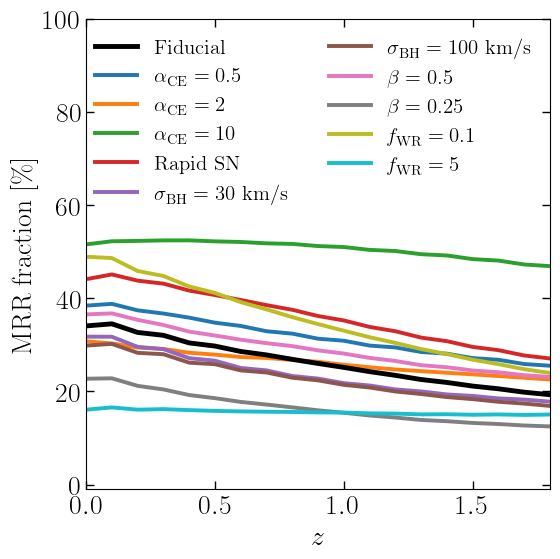

In [2]:
fig, ax = plt.subplots(figsize=(6, 6))

for cfg in compas_configs:
    path = find_matching_file(cfg, yield_files)
    if path is None:
        print(f"[WARN] No file found for tag '{cfg['tag']}' (patterns={cfg.get('match_any', [])})")
        continue
    print(f"[INFO] {cfg['tag']} -> {os.path.basename(path)}")
    z, percent_mrr = compute_percent_mrr(path)
    lw     = 3.5 if cfg["tag"] == "fiducial" else 2.8
    zorder = 5   if cfg["tag"] == "fiducial" else 2
    ax.plot(z, percent_mrr, label=cfg["label"], color=cfg["color"],
            ls="-", lw=lw, zorder=zorder)

ax.set_xlabel("$z$")
ax.set_ylabel(r"MRR fraction [$\%$]")
ax.set_xlim(0, 1.8)
ax.set_ylim(-1, 100)
ax.legend(ncols=2, frameon=False, loc="upper right",fontsize=15)

plt.tight_layout()
plt.savefig("../plots/final-percent_MRR_vs_z_COMPAS_all_models.pdf")
plt.show()